<a href="https://colab.research.google.com/github/vidaurre/glhmm/blob/main/docs/notebooks/HMM_state_selection_standard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HMM State Selection: Standard (Batch) Training
#### with the [glhmm toolbox](https://github.com/vidaurre/glhmm)

This notebook shows you how to choose the number of hidden states (K) for an HMM trained
on neuroimaging data using **standard (full-batch) EM training** — the simplest approach,
where all data sit in memory and the algorithm sees the full dataset on every update cycle.
Works well for small-to-medium datasets.

If your data are too large to fit in RAM, see
**[HMM_state_selection_stochastic](HMM_state_selection_stochastic.ipynb)** instead.

We look at two things to pick K:
- **Stability (Gamma similarity):** do you get the same solution if you train twice from
  different random starts? High, consistent similarity means yes.
- **Free energy:** how well does the model fit the data? Lower is better — look for an
  elbow where adding more states stops making much difference.

> ⚠️ Choose K **before** doing any downstream analysis. If you pick K based on which gives
> the best results, you're leaking information and the findings won't hold up.

**Reference:** Vidaurre et al. (2023), *glhmm: a Python toolbox for generalised linear hidden
Markov modelling*, [GitHub](https://github.com/vidaurre/glhmm)

### Objective

> **Research question:** What number of hidden states (K) best captures the structure
> in my neuroimaging data?

### Dataset

This demo uses a small synthetic dataset (`data_sim.npy`) that can be downloaded
automatically in the next cell. The dataset was originally created by **Christine Ahrends** as part of the
glhmm prediction tutorial — see
[Prediction_tutorial.ipynb](https://github.com/vidaurre/glhmm/blob/main/docs/notebooks/Prediction_tutorial.ipynb).

Replace `PATH_DATA` / `FILE_NAME` with your own data when applying this to real data.

Expected data format: NumPy array of shape `(n_timepoints, n_subjects, n_features)`.

Authors: Nick Yao Larsen <nylarsen@cfin.au.dk>

## Table of Contents

- [Part 1 - Data Preparation](#part1)
  - [Step 1 - Load data](#step1)
  - [Step 2 - Preprocess](#step2)
  - [Step 3 - Configure training settings](#step3)
- [Part 2 - Standard Batch HMM Training](#part2)
  - [Step 4 - Train HMMs](#step4)
  - [Load saved results](#load)
- [Part 3 - Model Selection](#part3)
  - [Step 5 - Visualise stability and model fit](#step5)
  - [Step 6 - Choose K](#step6)


### Import libraries

In [1]:
# Install the GLHMM_package when using Google Colab
try:
    import google.colab
    IN_COLAB = True
    !pip install -q git+https://github.com/vidaurre/glhmm
except ImportError:
    IN_COLAB = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glhmm import glhmm, preproc, utils, statistics, graphics



### Download demo data

The cell below checks whether the demo dataset is already present in the `data/`
folder and downloads it from OSF automatically if not. **Skip this cell if you are
using your own data** => point `PATH_DATA` at your data folder in Step 1 instead.


In [2]:
utils.osf_download_data('https://osf.io/8qcyj/', folder='Simulation_data_numpy')

Files already present in data/.


## Part 1 - Data Preparation <a id='part1'></a>


### Step 1. Load data <a id='step1'></a>

The demo dataset contains 100 synthetic subjects, each with 4800 time points and 50 features.

To use your own data, replace `PATH_DATA` and `FILE_NAME` and ensure the array has shape
`(n_timepoints, n_subjects, n_features)` with equal timepoints across subjects.

Also, the demonstration includes the indices that belong to each subject and is stored in `idx_data`.

In [3]:
# ── User settings ─────────────────────────────────────────────────────────
PATH_DATA = Path('data')          # folder containing demo_data.npy
FILE_NAME = 'data_sim.npy'
# ──────────────────────────────────────────────────────────────────────────

Y = np.load(PATH_DATA / FILE_NAME)
idx_data = np.load(PATH_DATA / 'idx_data.npy')
n_timepoints, n_subjects, n_features = Y.shape

print(f'Data shape : {Y.shape}')
print(f'  Timepoints per subject : {n_timepoints}')
print(f'  Subjects               : {n_subjects}')
print(f'  Features               : {n_features}')

print(f'Index of data samples :\n {idx_data[:3]}\n ...\n{idx_data[-3:]}')

Data shape : (4800, 100, 50)
  Timepoints per subject : 4800
  Subjects               : 100
  Features               : 50
Index of data samples :
 [[    0  4800]
 [ 4800  9600]
 [ 9600 14400]]
 ...
[[465600 470400]
 [470400 475200]
 [475200 480000]]


### Step 2. Preprocess data <a id='step2'></a>

Reshape the data from 3-D to 2-D (all subjects stacked along the time axis), then
z-score each subject's time series with `preproc.preprocess_data()`.

In [4]:
# Reshape (n_timepoints, n_subjects, n_features) -> (n_subjects * n_timepoints, n_features)
# Be careful with this step when using real data 
# this function assumes the the length for each subject is the same, and that the data are ordered by subject 
# (i.e. all timepoints for subject 1, then all timepoints for subject 2, etc.). 
# If this is not the case, you will need to reshape the data manually and adjust the index array accordingly.

Y_2d = statistics.get_concatenate_subjects(Y) 

Y_preproc, idx_preproc, log_preproc = preproc.preprocess_data(Y_2d, idx_data, standardise=True)

print(f'Preprocessed shape : {Y_preproc.shape}')
print(f'Index array shape  : {idx_preproc.shape}')


Preprocessed shape : (480000, 50)
Index array shape  : (100, 2)


### Step 3. Configure training settings <a id='step3'></a>

For the demo we test K = 3 to 8, running 5 independent repetitions per K.

For real data, use a wider range (e.g. 5–12) and more repetitions (10).

Each pair of runs is compared with `get_gamma_similarity()`. With `n_repeats` runs,
the number of unique pairs is:

$$\binom{n}{2} = \frac{n(n-1)}{2}$$

With `n_repeats = 5` you get **10 comparisons** per K — every possible pair, not just
"run 1 vs. all others". That matters because run 1 might itself be a bad initialisation.

In [5]:
# ── Model settings ───────────────────────────────────────────────────────
COVTYPE    = 'full'   # 'full' | 'diag' | 'shareddiag' | 'sharedfull'
MODEL_MEAN = 'no'     # 'no' (standardised data) | 'state' (raw activation levels)
# ──────────────────────────────────────────────────────────────────────────
state_range = range(3, 9)    # K values to evaluate (3, 4, 5, 6, 7, 8)
n_repeats   = 5              # independent runs per K
SAVE_DIR    = Path.cwd() / 'results_standard'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'K values    : {list(state_range)}')
print(f'Repetitions : {n_repeats}')
print(f'Results dir : {SAVE_DIR}')


K values    : [3, 4, 5, 6, 7, 8]
Repetitions : 5
Results dir : c:\Users\au323479\Github\glhmm_protocols\Procedures\results_standard


## Part 2 - Standard Batch HMM Training <a id='part2'></a>

For each K and each random seed we:
1. Initialise an HMM with `covtype='full'`.
2. Train using full-batch EM until convergence or `cyc` cycles.
3. After all runs are done, compute all **N*(N-1)/2 pairwise** Gamma similarities —
   every pair, not just comparisons to run 0.
4. Save each model immediately so nothing is lost if something crashes.

### Step 4. Train HMMs <a id='step4'></a>

Key model settings (set in the cell above):

| Parameter | Default | When to change |
|-----------|---------|----------------|
| `COVTYPE` | `'full'` | Use `'diag'` for speed with many features; `'sharedfull'` for one shared FC matrix |
| `MODEL_MEAN` | `'no'` | Change to `'state'` if your data are **not** mean-centred and activation levels carry information |

**Why `covtype='full'`?**
Each state gets its own full covariance matrix, so each state describes a distinct
functional connectivity (FC) pattern. This is the most informative structure for
neuroimaging and works best for downstream analyses that rely on per-state covariances
(e.g. the Fisher kernel). Cheaper options like `'diag'` drop the off-diagonal correlations;
`'sharedfull'` uses one shared FC matrix across all states — both lose the per-state
connectivity structure.

**Why `model_mean='no'`?**
Standard fMRI preprocessing (z-scoring, normalisation) removes the session mean, so there
is nothing for the model to estimate as a per-state activation level. Estimating it anyway
just adds free parameters that carry no signal and can slow convergence. Switch to `'state'`
only if your data still has meaningful absolute activation differences between states.

Training options (`cyc`, `min_cyc`, `verbose`) go in the `options` dict below.

In [ ]:
# ── Training options ──────────────────────────────────────────────────────
# ⚠️  Demo values — for real data use higher
options = {
    'cyc':     100,   # demo only — increase for real data
    'min_cyc': 10,    # demo only
    'verbose': False,
}
# ──────────────────────────────────────────────────────────────────────────

results = utils.run_stability_training(
    Y_preproc, idx_data, state_range, n_repeats, SAVE_DIR,
    log_preproc=log_preproc,
    covtype=COVTYPE,
    model_mean=MODEL_MEAN,
    options=options,
)

### Load saved results <a id='load'></a>

Run this cell **instead of the training cell above** if results already exist.

- **Case A:** `summary_results.pkl` present -> loads directly.
- **Case B:** Only individual `hmm_K*_rep*.pkl` files -> rebuilds the summary.


In [7]:
results, state_range = utils.load_stability_results(SAVE_DIR)

Loaded summary_results.pkl  (K = [3, 4, 5, 6, 7, 8])

    K | N reps | N sim scores |   Min final FE
--------------------------------------------
   3 |      5 |           10 |    32100085.75
   4 |      5 |           10 |    32023294.39
   5 |      5 |           10 |    31921052.49
   6 |      5 |           10 |    31873007.22
   7 |      5 |           10 |    31839304.50
   8 |      5 |           10 |    31810769.20


## Part 3 - Model Selection <a id='part3'></a>


### Step 5. Visualise stability and model fit <a id='step5'></a>

Three panels:

1. **Gamma Similarity (violin)** — all C(n_repeats, 2) pairwise similarity scores per K
   (10 scores for `n_repeats=5`). The red line is the mean; a narrow violin means stable.
   Grey dashed line marks the 0.8 threshold.

2. **Free Energy Elbow** — normalised minimum free energy vs K. Lower = better fit.
   The grey dashed line marks the elbow — where adding more states stops paying off.

3. **Convergence Curves** — free energy over EM cycles for the best run per K.
   Curves should plateau; still going down means you need more cycles.

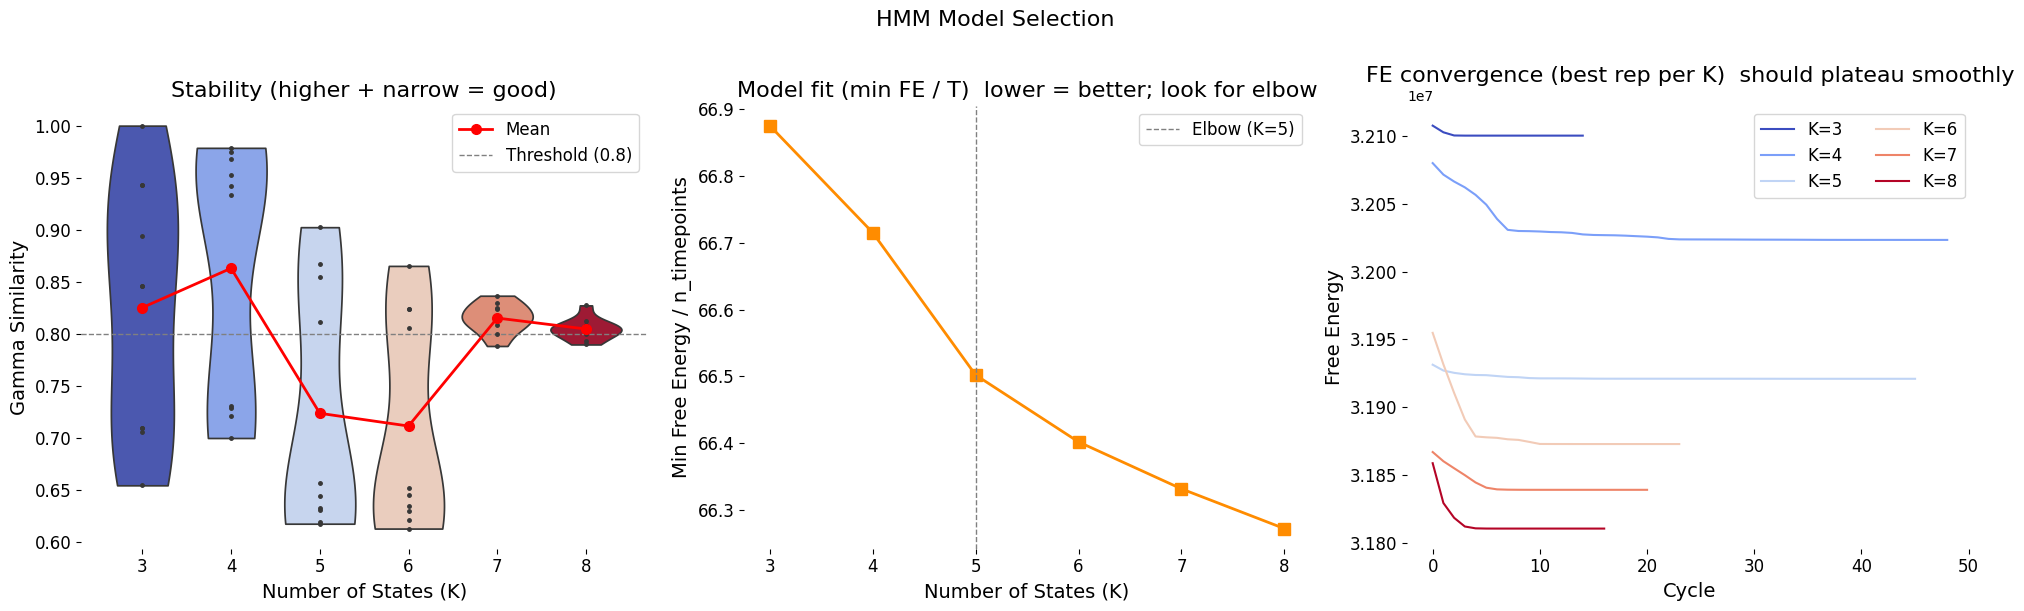

    K |  Mean Sim |  Std Sim |   Min FE/T | Converged?
----------------------------------------------------
   3 |    0.8253 |   0.1157 |      66.88 |        yes
   4 |    0.8631 |   0.1175 |      66.72 |        yes
   5 |    0.7239 |   0.1128 |      66.50 |        yes
   6 |    0.7116 |   0.0978 |      66.40 |        yes
   7 |    0.8153 |   0.0136 |      66.33 |        yes
   8 |    0.8048 |   0.0098 |      66.27 |        yes


In [8]:
avg_similarity, min_fe = graphics.plot_model_selection(
    results, Y_preproc.shape[0],
    save_path=str(SAVE_DIR / 'model_selection.png'),
)

### Step 6. Choose K <a id='step6'></a>

Look at the two panels together:

- **Stability first:** skip any K where the mean Gamma similarity is below 0.8 or the
  violin is very wide. A wide spread means the algorithm lands in different solutions
  depending on the random start — that K is not reliable.

- **Free energy elbow:** among the stable K values, go with the one at or just before
  the elbow. Beyond the elbow, more states keep improving the fit but only by a little.

- **Convergence:** `CHECK` means the best run had not fully converged — increase `cyc`
  or `min_cyc` before trusting those numbers.

#### When the two criteria point to different K

This happens. For example:

- The **elbow** is at K=5 because the biggest single drop in free energy happens at
  K=4→K=5. After that, gains shrink.

- A **higher K** (e.g. K=8) might still be stable and have an even tighter violin —
  meaning the algorithm reliably finds the same solution regardless of random start.
  It also fits the data better.

Both can be reasonable. A few things to consider:

| | Prefer lower K (elbow) | Prefer higher K |
|---|---|---|
| Parsimony | Simpler model, fewer parameters | — |
| Fragmentation risk | — | Higher K may split one real state into two near-identical ones, especially with limited data |
| Scientific goal | — | More states can capture finer differences between individuals |
| Data size | Small dataset → higher K overfits | Large dataset → higher K is more viable |

> **Rule of thumb:** if a higher K is stable *and* has a clearly tighter violin, validate
> it with your downstream analysis and compare. If results look similar, go with the simpler model.

> **Note on demo data:** 100 subjects, demo cycle counts — results will vary with more data
> or longer training. Don't read too much into the specific K values here.

#### How many states do you actually need?

The elbow and stability plots give you a data-driven starting point, but not the final
answer — especially in two situations:

**Large datasets (e.g. EEG):** Free energy keeps going down with more states because large
datasets always support finer-grained structure. The elbow can land at a K that is too high
to be meaningful. In that case, lean on stability — pick the highest K that still gives
stable solutions, and treat the elbow as a ceiling rather than a target.

**Question-driven K:** If your research question implies a certain number of states (e.g.
you are looking for a few distinct brain networks), let the question guide you. Use the plots
to check that your chosen K is stable and that free energy is not nosediving — but you do not
have to follow the elbow.

> **Bottom line:** pick the K that is stable, makes sense for your question, and is as
> simple as it can be without losing important structure.

Set `CHOSEN_K` below. **Don't change it once you've looked at any downstream results.**

In [10]:
CHOSEN_K = 5   # <- set after inspecting plots, e.g. CHOSEN_K = 5

if CHOSEN_K is None:
    raise ValueError('Set CHOSEN_K based on the stability and free energy plots above.')

best_rep = int(np.argmin([fe[-1] for fe in results[CHOSEN_K]['FE']]))
print(f'Chosen K = {CHOSEN_K}')
print(f'Best repetition: {best_rep + 1}  (lowest final free energy)')
print(f'Mean stability : {avg_similarity[CHOSEN_K]:.4f}')
print(f'Min FE/T       : {min_fe[CHOSEN_K]:.4f}')


Chosen K = 5
Best repetition: 4  (lowest final free energy)
Mean stability : 0.7239
Min FE/T       : 66.5022
